# Caso 8 - Analizando la influencia de las políticas tributarias en la calidad de la educación

En este caso usaremos varias bases de datos de la OCDE para estudiar cómo las políticas tributarias, la población y otras características económicas de un país tienen influencia en la calidad educativa medida por las pruebas PISA. Usaremos 2 resultados de la prueba, el de 2015 y el de 2018, y un histórico de valores socioeconómicos de los paises para tratar de establecer una correlación. El modelo a usar será una regresión lineal, que implementaremos haciendo uso de la librería de `statsmodels`.<br>


## Resultado Previsto de Aprendizaje
Al finalizar este caso, el estudiante reforzará el uso de la función `merge` para unir bases de datos y las funciones `melt` y `pivot` para cambiar la estructura de las bases de datos. También aprenderá a usar la librería `statsmodels` para hacer análisis de regresión lineal y hacer inferencia sobre la correlación entre las variables de entrada y la variable de salida.

________

## Contexto del Problema

Usted trabaja como analista en la OCDE y desea entregar un informe que le permita a los países conocer si hay una relación entre las características socioeconómicas del país y la calidad educativa. Como referencia, usará las pruebas PISA, una prueba internacional que se aplica a los estudiantes de bachillerato de un grupo significativo de paises.

## Librerías Requeridas
Para instalar la librería `statsmodels` debemos activar el ambiente de trabajo y ejecutar:
- Con Anaconda:
    `conda install statsmodels`

- Con PIP:
    `pip install statsmodels`

Iniciamos entonces importando las librerías que necesitamos

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

## Importando los datos correspondientes a las pruebas PISA

Para comenzar a trabajar el caso, importaremos los datos correspondientes a las pruebas PISA de los años 2015 y 2018 para un conjunto de países. Al igual que todas las bases de datos de este caso, los datos han sido obtenidos del Explorador de Datos de la OCDE

https://data-explorer.oecd.org/

Importemos entonces la base de datos usando Pandas


In [2]:
pisa_df = pd.read_excel('data/pruebas_PISA.xlsx', # la posición del archivo
                        header = 5, # el número de líneas a ignorar al principio
                        skipfooter = 2, # el número de líneas a ignorar al final
                        names = ['pais', '','2015', '2018',''] # Los nombres de las columnas
                        )

Veamos el resultado

In [3]:
pisa_df

,pais,,2015,2018,.1
0,Country,NaN,NaN,NaN,NaN
1,Indicator: Reading performance (PISA),NaN,NaN,NaN,NaN
2,Australia,NaN,503.0,503.0,NaN
3,Austria,NaN,485.0,484.0,NaN
4,Belgium,NaN,499.0,493.0,NaN
...,...,...,...,...,...
122,United Kingdom,NaN,509.0,505.0,NaN
123,United States,NaN,496.0,502.0,NaN
124,Brazil,NaN,401.0,404.0,NaN
125,Indonesia,NaN,403.0,396.0,NaN


En efecto hemos cargado la base de datos adecuadamente, pero tenemos el problema de que la primera fila no tiene información. Adicionalmente se cargaron dos columnas que no tienen ninguna información:

In [4]:
pisa_df.drop(index=0, inplace = True)
pisa_df.dropna(how = 'all', axis = 'columns', inplace=True)
pisa_df

,pais,2015,2018
1,Indicator: Reading performance (PISA),NaN,NaN
2,Australia,503.0,503.0
3,Austria,485.0,484.0
4,Belgium,499.0,493.0
5,Canada,527.0,520.0
...,...,...,...
122,United Kingdom,509.0,505.0
123,United States,496.0,502.0
124,Brazil,401.0,404.0
125,Indonesia,403.0,396.0


Listo, ya hemos arreglado bastante nuestra base de datos. Tenemos sin embargo todavía el problema de que hay varias filas en las que el nombre del país es el separador del indicador que estamos estudiando.

In [ ]:
pisa_df[pisa_df['pais'].str.contains('Indicator')].astype(str)

,pais,2015,2018
1,Indicator: Reading performance (PISA),NaN,NaN
43,Indicator: Mathematics performance (PISA),NaN,NaN
85,Indicator: Science performance (PISA),NaN,NaN


Como se ve, esto ocurre en tres líneas que usaremos como separadores. El proceso que llevaremos a cabo para organizar nuestra base de datos será el siguiente:
- Crearemos una nueva columna llamada `indicador`.
- En esa columna agregaremos el valor `lectura`, `matemáticas` o `ciencias` según corresponda.
- Finalmente transformaremos la base de datos para que toda la información quede en formato largo, es decir, que el año también aparezca en una nueva columna.

Veamos como implementar todas estas transformaciones

In [6]:
# Creando una nueva columna llamada indicador
pisa_df['indicador'] = np.nan

Podríamos poner las posiciones de los separadores manualmente, pero veamos cómo hacerlo de manera automática

In [7]:
 pisa_df[pisa_df['pais'].str.contains('Indicator')].index

RangeIndex(start=1, stop=127, step=42)

In [14]:
pisa_df.dtypes

pisa_df['indicador'] = pisa_df['indicador'].astype('str')

In [15]:
# creando una lista con las posiciones del separador
sep_pos = pisa_df[pisa_df['pais'].str.contains('Indicator')].index

# diccionario relacionando el nombre del indicador y el valor que deseamos poner en la columna
nombres = {'Reading':'lectura', 'Mathematics':'matematicas','Science': 'ciencias'}

# iteramos sobre los separadores
for i in range(len(sep_pos)):
    # obtenemos el nombre del separador
    sep_name = pisa_df.loc[sep_pos[i],'pais']
    # ahora buscamos con cual nombre corresponde
    for key in nombres.keys():
        if key in sep_name:
            nombre = nombres[key]
            break # cuando la encuentra, salimos del for
    # llenamos los valores con el nombre que encontramos
    try: # este código fallara para el último separador
        pisa_df.loc[sep_pos[i]:sep_pos[i+1], 'indicador'] = nombre
    except IndexError: # para el último simplemente vamos hasta el final
        pisa_df.loc[sep_pos[i]:, 'indicador'] = nombre

# ahora finalmente eliminamos las filas con los indicadores
pisa_df.drop(index = sep_pos, inplace=True)

pisa_df


,pais,2015,2018,indicador
2,Australia,503.0,503.0,lectura
3,Austria,485.0,484.0,lectura
4,Belgium,499.0,493.0,lectura
5,Canada,527.0,520.0,lectura
6,Chile,459.0,452.0,lectura
...,...,...,...,...
122,United Kingdom,509.0,505.0,ciencias
123,United States,496.0,502.0,ciencias
124,Brazil,401.0,404.0,ciencias
125,Indonesia,403.0,396.0,ciencias



Ahora sólo nos falta adelgazar nuestra base de datos convirtiendo los años en una columna adicional

In [16]:
pisa_df = pd.melt(pisa_df, id_vars=['pais', 'indicador'], value_vars=['2015', '2018'], value_name='puntaje', var_name='año')
pisa_df

,pais,indicador,año,puntaje
0,Australia,lectura,2015,503.0
1,Austria,lectura,2015,485.0
2,Belgium,lectura,2015,499.0
3,Canada,lectura,2015,527.0
4,Chile,lectura,2015,459.0
...,...,...,...,...
241,United Kingdom,ciencias,2018,505.0
242,United States,ciencias,2018,502.0
243,Brazil,ciencias,2018,404.0
244,Indonesia,ciencias,2018,396.0


Revisemos los formatos de las variables

In [17]:
pisa_df.dtypes

pais             str
indicador        str
año              str
puntaje      float64
dtype: object

Es importante que el año sea interpretado como un número, entonces haremos la corrección:

In [18]:
pisa_df['año']= pisa_df['año'].astype(int)

In [19]:
pisa_df.dtypes

pais             str
indicador        str
año            int64
puntaje      float64
dtype: object

Ahora nuestra base de datos ya está lista para trabajar, veamos rápidamente cómo son los resultados de las pruebas para los diferentes países de la base de datos

C:\Users\victor.novoa\AppData\Local\Temp\ipykernel_26564\1993259425.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, 'Australia'),
 Text(1, 0, 'Austria'),
 Text(2, 0, 'Belgium'),
 Text(3, 0, 'Canada'),
 Text(4, 0, 'Chile'),
 Text(5, 0, 'Colombia'),
 Text(6, 0, 'Costa Rica'),
 Text(7, 0, 'Czechia'),
 Text(8, 0, 'Denmark'),
 Text(9, 0, 'Estonia'),
 Text(10, 0, 'Finland'),
 Text(11, 0, 'France'),
 Text(12, 0, 'Germany'),
 Text(13, 0, 'Greece'),
 Text(14, 0, 'Hungary'),
 Text(15, 0, 'Iceland'),
 Text(16, 0, 'Ireland'),
 Text(17, 0, 'Israel'),
 Text(18, 0, 'Italy'),
 Text(19, 0, 'Japan'),
 Text(20, 0, 'Korea'),
 Text(21, 0, 'Latvia'),
 Text(22, 0, 'Lithuania'),
 Text(23, 0, 'Luxembourg'),
 Text(24, 0, 'Mexico'),
 Text(25, 0, 'Netherlands'),
 Text(26, 0, 'New Zealand'),
 Text(27, 0, 'Norway'),
 Text(28, 0, 'Poland'),
 Text(29, 0, 'Portugal'),
 Text(30, 0, 'Slovak Republic'),
 Text(31, 0, 'Slovenia'),
 Text(32, 0, 'Spain'),
 Text(33, 0, 'Sweden'),
 Text(34, 0, 'Switzerland'),
 Text(35, 0, 'Türkiye'),
 Text(36, 0, 'United Kingdom'),
 Text(37, 0, 'United States'),
 Text(38, 0, 'Brazil'),
 Text(39,

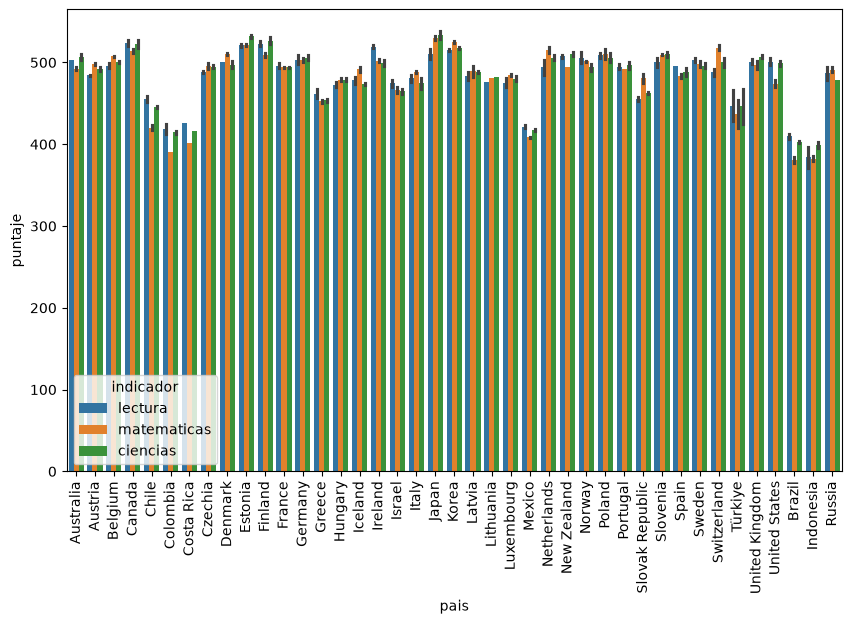

In [20]:
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(pisa_df, x='pais', y = 'puntaje', hue = 'indicador', ax = ax)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

Podemos observar cómo los paises latinoamericanos como Chile, Colombia, Costa Rica, Mexico y Brasil, junto con Indonesia, tienen los resultados más bajos en las pruebas PISA en la base de datos. Por otro lado, paises como Japón, Korea, Estonia, Finlandia y Canadá se destacan entre los puntajes más altos.

¿Qué determina el éxito en las pruebas? ¿Podemos encontrar alguna característica en estos países que los hace ser tan efectivos en los valores de las pruebas PISA?

## Cargando la población del país
Ahora cargaremos la base de datos con el histórico de la población de los países, esta base de datos también ha sido obtenida del Explorador de Datos de la OCDE

In [21]:
poblacion_df = pd.read_excel('data/population.xlsx', # la posición del archivo
                        header = 6, # el número de líneas a ignorar al principio
                        skipfooter = 2, # el número de líneas a ignorar al final
                        )

poblacion_df

,Time,Time.1,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,Unnamed: 12
0,Country,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Australia,NaN,21.691653,22.031750,22.340024,22.733465,23.128129,23.475686,23.815995,24.190907,24.594202,24.966643,NaN
2,Austria,NaN,8.341483,8.361069,8.388534,8.426311,8.477230,8.543932,8.629519,8.739806,8.795073,8.837707,NaN
3,Belgium,NaN,10.796498,10.895591,10.993609,11.067748,11.125033,11.179778,11.238474,11.295003,11.349081,11.403740,NaN
4,Canada,NaN,33.628895,34.004889,34.339328,34.714222,35.082954,35.437435,35.702908,36.109487,36.545236,37.065084,NaN
5,Chile,NaN,16.881078,17.063927,17.254159,17.443491,17.611902,17.787617,17.971423,18.167147,18.419192,18.751405,NaN
6,Colombia,NaN,43.608630,44.086292,44.553416,45.001571,45.434942,45.866010,46.313898,46.830116,47.419200,48.258494,NaN
7,Costa Rica,NaN,4.469337,4.533894,4.592149,4.652459,4.713168,4.773130,4.832234,4.890379,4.947490,5.003402,NaN
8,Czechia,NaN,10.491492,10.517247,10.496672,10.509286,10.510719,10.524783,10.542942,10.565284,10.589526,10.626430,NaN
9,Denmark,NaN,5.519441,5.543819,5.566856,5.587085,5.608784,5.639719,5.678348,5.724456,5.760694,5.789957,NaN


En este caso debemos eliminar la primera fila y un par de columnas que no tienen información. También hay que cambiarle el nombre a la primera columna. Hagamos todos estos arreglos

In [22]:
# eliminando las columnas que no tienen información
poblacion_df.dropna(how = 'all', axis = 'columns', inplace = True)

# eliminando la primera fila
poblacion_df.drop(index = 0, inplace = True)

# cambiando el nombre de la primera columna
poblacion_df.rename(columns={'Time':'pais'}, inplace=True)

poblacion_df

,pais,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
1,Australia,21.691653,22.031750,22.340024,22.733465,23.128129,23.475686,23.815995,24.190907,24.594202,24.966643
2,Austria,8.341483,8.361069,8.388534,8.426311,8.477230,8.543932,8.629519,8.739806,8.795073,8.837707
3,Belgium,10.796498,10.895591,10.993609,11.067748,11.125033,11.179778,11.238474,11.295003,11.349081,11.403740
4,Canada,33.628895,34.004889,34.339328,34.714222,35.082954,35.437435,35.702908,36.109487,36.545236,37.065084
5,Chile,16.881078,17.063927,17.254159,17.443491,17.611902,17.787617,17.971423,18.167147,18.419192,18.751405
6,Colombia,43.608630,44.086292,44.553416,45.001571,45.434942,45.866010,46.313898,46.830116,47.419200,48.258494
7,Costa Rica,4.469337,4.533894,4.592149,4.652459,4.713168,4.773130,4.832234,4.890379,4.947490,5.003402
8,Czechia,10.491492,10.517247,10.496672,10.509286,10.510719,10.524783,10.542942,10.565284,10.589526,10.626430
9,Denmark,5.519441,5.543819,5.566856,5.587085,5.608784,5.639719,5.678348,5.724456,5.760694,5.789957
10,Estonia,1.334515,1.331475,1.327439,1.322696,1.317997,1.314545,1.314608,1.315790,1.317384,1.321977


Verifiquemos que todos los valores para la población estén completos

In [23]:
poblacion_df.describe()

,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,87.956215,88.776346,89.546593,90.342257,91.129092,91.910740,92.661368,93.414942,94.152587,94.845047
std,249.140734,251.631873,254.110715,256.634642,259.148470,261.573879,263.877237,266.181101,268.481993,270.554367
min,0.318501,0.318044,0.319011,0.320723,0.323763,0.327379,0.330818,0.335435,0.343399,0.352722
25%,4.754886,4.805631,4.862854,4.927045,4.988420,5.046353,5.100482,5.149709,5.194596,5.234787
50%,10.951757,11.008468,11.049254,11.056379,11.045121,11.036096,11.029678,11.035484,11.051880,11.068309
75%,52.641886,53.276478,53.923384,54.572250,55.221193,55.857254,56.460203,57.043916,57.630590,58.224242
max,1339.125594,1348.191369,1357.095477,1366.560818,1376.100306,1385.189667,1393.715447,1401.889680,1410.275957,1417.069468


### Relacionando el histórico con el resultado de las pruebas

En lo siguiente vamos a hacer la siguiente suposición: los resultados de las pruebas en un año determinado dependen del promedio de los parámetros en los cinco años anteriores a la aplicación. Esto quiere decir que supondremos que el resultado de las pruebas en 2015 depende del promedio de la población entre 2009 y 2014; y los resultados del 2018 dependen del promedio de las pruebas entre 2013 y 2017.

Eso quiere decir que para cada país en nuestra base de datos debemos calcular 2 promedios de población. Para hacer este cálculo seguiremos el siguiente proceso:

- De nuevo haremos una transformación sobre la base de datos para cambiar a formato largo.
- Filtraremos la base de datos usando el rango de años requerido.
- Haremos un `groupby` para calcular el primer promedio por país.
- Posteriormente volveremos a la base de datos en formato largo y filtraremos por el nuevo rango de años.
- Haremos un `groupby`para calcular el segundo promedio por país.
- Uniremos los resultados de los dos promedios para crear una única base de datos.

In [24]:
poblacion_df = pd.melt(poblacion_df, id_vars=['pais'], var_name='año', value_name='poblacion')

In [25]:
poblacion_df

,pais,año,poblacion
0,Australia,2009,21.691653
1,Austria,2009,8.341483
2,Belgium,2009,10.796498
3,Canada,2009,33.628895
4,Chile,2009,16.881078
...,...,...,...
515,Romania,2018,19.483840
516,Russia,2018,146.830572
517,Saudi Arabia,2018,33.413660
518,Singapore,2018,3.994283


In [26]:
poblacion_df['año'] = poblacion_df['año'].astype(int)

In [27]:
prom_df = pd.DataFrame()

año = 2015
filtrado = poblacion_df[poblacion_df['año'].isin(np.arange(año-5,año))]
promedios = filtrado.groupby('pais')['poblacion'].mean().reset_index()
promedios['año'] = año

prom_df = pd.concat((prom_df, promedios), axis = 0)

año = 2018
filtrado = poblacion_df[poblacion_df['año'].isin(np.arange(año-5,año))]
promedios = filtrado.groupby('pais')['poblacion'].mean().reset_index()
promedios['año'] = año

prom_df = pd.concat((prom_df, promedios), axis = 0)

prom_df[prom_df['pais']=='Argentina']

,pais,poblacion,año
0,Argentina,41.731130,2015
0,Argentina,43.127916,2018


La base de datos ya está en el formato correcto, ahora podemos proceder a hacer el promedio. Sin embargo, como este proceso lo estaremos haciendo una y otra vez con diferentes bases de datos, podemos crear de entrada una función que incluya todo el código requerido.

In [28]:
def calcular_promedios(data, col_agrup, col_prom, años):
    ''' esta función calcula el promedio de una base de datos agrupando por las columnas col_agrup y promediando los valores de las columnas col_prom
        debe haber una columna llamada año para promediar sobre los últimos 5 años
    '''
    # nos aseguramos de que el año sea un número
    data['año'] = data['año'].astype(int)
    
    # creamos un DataFrame vacío
    promedio_df = pd.DataFrame()
    
    # hacemos un for sobre los años a promediar
    # el promedio es sobre año-6 a año-1
    for año in años:
        # filtramos la base a los años de interés
        filt_data = data[data['año'].isin(np.arange(año-5,año))]
        # creamos de nuevo un DataFrame vacío
        prom_df = pd.DataFrame()
        # hacemos un for sobre las columnas a promediar
        for col in col_prom:
            # agrupamos la base filtrada
            prom_data = filt_data.groupby(col_agrup)[col].mean()
            # agregamos al promedio general
            prom_df = pd.concat((prom_df,prom_data), axis = 1)
        # agregamos el año
        prom_df['año'] = año
        # finalmente hacemos un reset index y le cambiamos el nombre
        prom_df.reset_index(inplace = True)
        # y agregamos el resultado al promedio general
        promedio_df = pd.concat((promedio_df, prom_df), axis = 0)
        
    return promedio_df
        

Ahora podemos probar nuestra función:

In [29]:
poblacion_promedio = calcular_promedios(poblacion_df, ['pais'], ['poblacion'], [2015,2018])
poblacion_promedio

,index,poblacion,año
0,Argentina,41.731130,2015
1,Australia,22.741811,2015
2,Austria,8.439415,2015
3,Belgium,11.052352,2015
4,Brazil,198.306215,2015
...,...,...,...
47,Sweden,9.815289,2018
48,Switzerland,8.277112,2018
49,Türkiye,78.227739,2018
50,United Kingdom,65.100145,2018


Ahora que ya tenemos los promedios de población, podemos agregar esta información a la de las pruebas PISA

In [30]:
pisa_df

,pais,indicador,año,puntaje
0,Australia,lectura,2015,503.0
1,Austria,lectura,2015,485.0
2,Belgium,lectura,2015,499.0
3,Canada,lectura,2015,527.0
4,Chile,lectura,2015,459.0
...,...,...,...,...
241,United Kingdom,ciencias,2018,505.0
242,United States,ciencias,2018,502.0
243,Brazil,ciencias,2018,404.0
244,Indonesia,ciencias,2018,396.0


In [31]:
pisa_df = pisa_df.merge(poblacion_promedio, left_on=['pais','año'], right_on=['index', 'año'], how = 'left')
pisa_df

,pais,indicador,año,puntaje,index,poblacion
0,Australia,lectura,2015,503.0,Australia,22.741811
1,Austria,lectura,2015,485.0,Austria,8.439415
2,Belgium,lectura,2015,499.0,Belgium,11.052352
3,Canada,lectura,2015,527.0,Canada,34.715766
4,Chile,lectura,2015,459.0,Chile,17.432219
...,...,...,...,...,...,...
241,United Kingdom,ciencias,2018,505.0,United Kingdom,65.100145
242,United States,ciencias,2018,502.0,United States,320.675831
243,Brazil,ciencias,2018,404.0,Brazil,203.431748
244,Indonesia,ciencias,2018,396.0,Indonesia,256.474658


Quitemos la columna que nos ha quedado duplicada

In [32]:
pisa_df.drop(columns='index', inplace=True)
pisa_df

,pais,indicador,año,puntaje,poblacion
0,Australia,lectura,2015,503.0,22.741811
1,Austria,lectura,2015,485.0,8.439415
2,Belgium,lectura,2015,499.0,11.052352
3,Canada,lectura,2015,527.0,34.715766
4,Chile,lectura,2015,459.0,17.432219
...,...,...,...,...,...
241,United Kingdom,ciencias,2018,505.0,65.100145
242,United States,ciencias,2018,502.0,320.675831
243,Brazil,ciencias,2018,404.0,203.431748
244,Indonesia,ciencias,2018,396.0,256.474658


Ahora ya tenemos en cada caso la población promediada sobre los 5 años anteriores a la aplicación de la prueba.

## GDP per Capita
Tiene sentido pensar que el resultado de las pruebas pueda estar relacionado con el GDP (producto interno bruto) per capita del país. Esta información se encuentra en la siguiente base de datos

In [33]:
gdp_df = pd.read_excel('data/GDP.xlsx', # ubicación del archivo),
                        header = 5, # el número de líneas a ignorar al principio
                        skipfooter = 2, # el número de líneas a ignorar al final
                        )

gdp_df

,Time,Time.1,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,Unnamed: 12
0,Country,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Indicator: Gross domestic product (GDP),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Australia,NaN,41684.568650,42823.927966,44460.605016,43911.683304,47796.022174,47648.633963,47266.591718,50152.476571,50758.582318,53118.792237,NaN
3,Austria,NaN,40925.933876,42013.885754,44469.209642,46477.655075,47936.677963,48813.534409,49942.056293,52665.087457,54188.360666,56956.110562,NaN
4,Belgium,NaN,37748.389212,39833.141536,40942.230717,42290.858433,43671.146878,44929.532494,46200.866290,48597.487117,50442.060625,52530.381806,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,Senegal,NaN,2669.497855,2714.467736,2728.699987,2798.104708,2797.721619,2881.298928,3017.267768,3116.185752,3238.212275,3416.702758,NaN
60,Serbia,NaN,12534.121646,12797.633806,13742.308610,13929.194018,14624.154719,14657.017285,14928.464737,15858.125439,16611.076320,17717.949847,NaN
61,Singapore,NaN,66206.649365,75385.788553,80047.573570,82071.712428,83004.278288,84418.931597,86974.779015,89499.532537,95338.443401,100636.969561,NaN
62,South Africa,NaN,12628.696151,12994.908386,13503.769127,13356.612371,13787.935830,13815.551011,13941.996711,14006.152389,14134.028896,14545.431392,NaN


Aplicamos los mismos ajustes que en las bases de datos anteriores

In [34]:
# quitamos columnas vacías
gdp_df.dropna(how = 'all', axis = 'columns', inplace=True)

# quitamos las dos primeras filas
gdp_df.drop(index=[0,1], inplace = True)

# cambiamos el nombre de la primera columna
gdp_df.rename(columns={'Time':'pais'}, inplace=True)

gdp_df

,pais,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
2,Australia,41684.568650,42823.927966,44460.605016,43911.683304,47796.022174,47648.633963,47266.591718,50152.476571,50758.582318,53118.792237
3,Austria,40925.933876,42013.885754,44469.209642,46477.655075,47936.677963,48813.534409,49942.056293,52665.087457,54188.360666,56956.110562
4,Belgium,37748.389212,39833.141536,40942.230717,42290.858433,43671.146878,44929.532494,46200.866290,48597.487117,50442.060625,52530.381806
5,Canada,38865.406022,40099.497886,41666.718851,42290.879082,44298.514462,45753.782936,44670.054374,46472.368771,48317.191163,49992.811418
6,Chile,16028.549544,18041.314313,20235.570348,21458.812331,22295.740021,22650.712398,22563.582179,23384.612377,24479.458726,25496.431051
...,...,...,...,...,...,...,...,...,...,...,...
59,Senegal,2669.497855,2714.467736,2728.699987,2798.104708,2797.721619,2881.298928,3017.267768,3116.185752,3238.212275,3416.702758
60,Serbia,12534.121646,12797.633806,13742.308610,13929.194018,14624.154719,14657.017285,14928.464737,15858.125439,16611.076320,17717.949847
61,Singapore,66206.649365,75385.788553,80047.573570,82071.712428,83004.278288,84418.931597,86974.779015,89499.532537,95338.443401,100636.969561
62,South Africa,12628.696151,12994.908386,13503.769127,13356.612371,13787.935830,13815.551011,13941.996711,14006.152389,14134.028896,14545.431392


Estamos listos para cambiar la forma de nuestra base de datos

In [35]:
gdp_df = pd.melt(gdp_df, id_vars=['pais'], var_name='año', value_name='gdp_pc')
gdp_df

,pais,año,gdp_pc
0,Australia,2009,41684.568650
1,Austria,2009,40925.933876
2,Belgium,2009,37748.389212
3,Canada,2009,38865.406022
4,Chile,2009,16028.549544
...,...,...,...
615,Senegal,2018,3416.702758
616,Serbia,2018,17717.949847
617,Singapore,2018,100636.969561
618,South Africa,2018,14545.431392


Ahora podemos calcular el promedio del producto interno bruto en los años precedentes a la aplicación de las pruebas, y agregarlo a la base de datos de las pruebas

In [36]:
gdp_prom = calcular_promedios(gdp_df, ['pais'], ['gdp_pc'], [2015, 2018])
gdp_prom

,index,gdp_pc,año
0,Albania,10438.501861,2015
1,Argentina,19368.589252,2015
2,Australia,45328.174485,2015
3,Austria,45942.192569,2015
4,Belgium,42333.382012,2015
...,...,...,...
57,Switzerland,65176.564607,2018
58,Türkiye,25444.600916,2018
59,United Kingdom,42773.919395,2018
60,United States,56346.684972,2018


Agregando la información a las pruebas PISA

In [37]:
pisa_df = pisa_df.merge(gdp_prom, left_on=['pais','año'], right_on=['index', 'año'], how = 'left').drop(columns='index')

In [38]:
pisa_df

,pais,indicador,año,puntaje,poblacion,gdp_pc
0,Australia,lectura,2015,503.0,22.741811,45328.174485
1,Austria,lectura,2015,485.0,8.439415,45942.192569
2,Belgium,lectura,2015,499.0,11.052352,42333.382012
3,Canada,lectura,2015,527.0,34.715766,42821.878643
4,Chile,lectura,2015,459.0,17.432219,20936.429882
...,...,...,...,...,...,...
241,United Kingdom,ciencias,2018,505.0,65.100145,42773.919395
242,United States,ciencias,2018,502.0,320.675831,56346.684972
243,Brazil,ciencias,2018,404.0,203.431748,15040.744740
244,Indonesia,ciencias,2018,396.0,256.474658,10527.761524


## Agregando la inversión en educación del país

Ahora agregaremos a nuestra base de datos, el porcentaje del GDP que el país invierte en educación primaria y secundaria. De nuevo, esta información ha sido obtenida directamente de la OCDE

In [39]:
investment_df = pd.read_excel('data/public_spending_on_education.xlsx', # ubicación del archivo),
                        header = 6, # el número de líneas a ignorar al principio
                        skipfooter = 2, # el número de líneas a ignorar al final
                        )

investment_df

,Time,Time.1,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,Unnamed: 12
0,Country,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Australia,NaN,3.558342,3.788551,3.489743,3.295539,3.257943,3.206929,3.181980,3.193161,3.231380,3.307333,NaN
2,Austria,NaN,NaN,NaN,NaN,2.993731,3.071253,2.979963,2.980174,2.988191,2.941086,2.827367,NaN
3,Belgium,NaN,4.152045,4.142179,4.129149,4.176546,4.183889,4.121513,4.053206,4.044523,4.010449,3.975536,NaN
4,Canada,NaN,3.324768,3.539711,3.414058,3.339135,3.265116,3.197652,3.170711,3.259800,3.259545,3.221834,NaN
5,Chile,NaN,3.031165,2.673376,2.632025,2.929083,2.646546,2.466476,2.630576,2.994949,3.000646,3.023450,NaN
6,Colombia,NaN,3.506992,3.281409,3.111201,3.019483,3.291633,3.093037,3.123892,3.065175,3.152782,3.204235,NaN
7,Costa Rica,NaN,4.359462,4.820263,4.587046,4.754158,4.701076,4.659144,4.847132,4.551488,NaN,3.882851,NaN
8,Czechia,NaN,2.491078,2.431169,2.453234,2.486302,2.415625,2.390923,2.408261,2.278536,2.436761,2.684517,NaN
9,Denmark,NaN,4.505544,4.553352,4.133907,4.513423,4.445553,4.674357,NaN,3.829105,3.733292,3.697377,NaN


Arreglemos entonces nuestra base de datos

In [40]:
# quitamos columnas vacías
investment_df.dropna(how = 'all', axis = 'columns', inplace=True)

# quitamos las dos primeras filas
investment_df.drop(index=[0], inplace = True)

# cambiamos el nombre de la primera columna
investment_df.rename(columns={'Time':'pais'}, inplace=True)

investment_df

,pais,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
1,Australia,3.558342,3.788551,3.489743,3.295539,3.257943,3.206929,3.181980,3.193161,3.231380,3.307333
2,Austria,NaN,NaN,NaN,2.993731,3.071253,2.979963,2.980174,2.988191,2.941086,2.827367
3,Belgium,4.152045,4.142179,4.129149,4.176546,4.183889,4.121513,4.053206,4.044523,4.010449,3.975536
4,Canada,3.324768,3.539711,3.414058,3.339135,3.265116,3.197652,3.170711,3.259800,3.259545,3.221834
5,Chile,3.031165,2.673376,2.632025,2.929083,2.646546,2.466476,2.630576,2.994949,3.000646,3.023450
6,Colombia,3.506992,3.281409,3.111201,3.019483,3.291633,3.093037,3.123892,3.065175,3.152782,3.204235
7,Costa Rica,4.359462,4.820263,4.587046,4.754158,4.701076,4.659144,4.847132,4.551488,NaN,3.882851
8,Czechia,2.491078,2.431169,2.453234,2.486302,2.415625,2.390923,2.408261,2.278536,2.436761,2.684517
9,Denmark,4.505544,4.553352,4.133907,4.513423,4.445553,4.674357,NaN,3.829105,3.733292,3.697377
10,Estonia,4.026403,3.747700,3.239097,3.149691,3.097016,2.618870,2.711455,2.691220,2.762699,2.954122


Como vemos, en esta base sí hay varios valores nulos. Esto no es un problema, simplemente estos valores no serán tenidos en cuenta a la hora de sacar los promedios históricos. Convirtamos la base a formato largo

In [41]:
investment_df = pd.melt(investment_df, id_vars=['pais'], var_name='año', value_name='ed_inv')
investment_df

,pais,año,ed_inv
0,Australia,2009,3.558342
1,Austria,2009,NaN
2,Belgium,2009,4.152045
3,Canada,2009,3.324768
4,Chile,2009,3.031165
...,...,...,...
465,India,2018,NaN
466,Indonesia,2018,NaN
467,Romania,2018,1.684485
468,Russia,2018,2.276071


Ahora podemos entonces calcular los promedios

In [42]:
investment_prom = calcular_promedios(investment_df, ['pais'], ['ed_inv'], [2015,2018])
investment_prom

,index,ed_inv,año
0,Argentina,3.807332,2015
1,Australia,3.407741,2015
2,Austria,3.014982,2015
3,Belgium,4.150655,2015
4,Brazil,4.109068,2015
...,...,...,...
42,Sweden,3.702404,2018
43,Switzerland,3.218681,2018
44,Türkiye,2.520684,2018
45,United Kingdom,3.875473,2018


Agreguemos esta información a la base de datos de las pruebas

In [43]:
pisa_df = pisa_df.merge(investment_prom, left_on=['pais','año'], right_on=['index', 'año'], how = 'left').drop(columns='index')

In [44]:
pisa_df

,pais,indicador,año,puntaje,poblacion,gdp_pc,ed_inv
0,Australia,lectura,2015,503.0,22.741811,45328.174485,3.407741
1,Austria,lectura,2015,485.0,8.439415,45942.192569,3.014982
2,Belgium,lectura,2015,499.0,11.052352,42333.382012,4.150655
3,Canada,lectura,2015,527.0,34.715766,42821.878643,3.351134
4,Chile,lectura,2015,459.0,17.432219,20936.429882,2.669501
...,...,...,...,...,...,...,...
241,United Kingdom,ciencias,2018,505.0,65.100145,42773.919395,3.875473
242,United States,ciencias,2018,502.0,320.675831,56346.684972,3.207156
243,Brazil,ciencias,2018,404.0,203.431748,15040.744740,4.065232
244,Indonesia,ciencias,2018,396.0,256.474658,10527.761524,2.350309


## Agregando información de recolección de impuestos
Ahora trabajaremos la base de datos más compleja, la de recolección de impuestos. Esta es una base de datos en formato `.csv` y tiene mucha información que no necesitamos, así que debemos ser cuidadosos en cómo la procesamos. Veamos

In [45]:
impuestos_df = pd.read_csv('data/recoleccion_de_impuestos.csv')
impuestos_df

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,MEASURE,Measure,SECTOR,Institutional sector,...,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,REVENUE_CODE,Revenue code,DECIMALS,Decimals,CURRENCY,Currency
0,DATAFLOW,OECD.CTP.TPS:DSD_REV_COMP_GLOBAL@DF_RSGLOBAL(1.0),Comparative tables of countries in the global ...,I,PHL,Philippines,TAX_REV,Tax revenue,S13,General government,...,A,Normal value,0,Units,3000,NaN,1,One,_Z,Not applicable
1,DATAFLOW,OECD.CTP.TPS:DSD_REV_COMP_GLOBAL@DF_RSGLOBAL(1.0),Comparative tables of countries in the global ...,I,PHL,Philippines,TAX_REV,Tax revenue,S13,General government,...,A,Normal value,0,Units,3000,NaN,1,One,_Z,Not applicable
2,DATAFLOW,OECD.CTP.TPS:DSD_REV_COMP_GLOBAL@DF_RSGLOBAL(1.0),Comparative tables of countries in the global ...,I,PHL,Philippines,TAX_REV,Tax revenue,S13,General government,...,A,Normal value,0,Units,3000,NaN,1,One,_Z,Not applicable
3,DATAFLOW,OECD.CTP.TPS:DSD_REV_COMP_GLOBAL@DF_RSGLOBAL(1.0),Comparative tables of countries in the global ...,I,PHL,Philippines,TAX_REV,Tax revenue,S13,General government,...,A,Normal value,0,Units,3000,NaN,1,One,_Z,Not applicable
4,DATAFLOW,OECD.CTP.TPS:DSD_REV_COMP_GLOBAL@DF_RSGLOBAL(1.0),Comparative tables of countries in the global ...,I,PHL,Philippines,TAX_REV,Tax revenue,S13,General government,...,A,Normal value,0,Units,3000,NaN,1,One,_Z,Not applicable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5539,DATAFLOW,OECD.CTP.TPS:DSD_REV_COMP_GLOBAL@DF_RSGLOBAL(1.0),Comparative tables of countries in the global ...,I,ATG,Antigua and Barbuda,TAX_REV,Tax revenue,S13,General government,...,A,Normal value,0,Units,2000,NaN,1,One,_Z,Not applicable
5540,DATAFLOW,OECD.CTP.TPS:DSD_REV_COMP_GLOBAL@DF_RSGLOBAL(1.0),Comparative tables of countries in the global ...,I,HND,Honduras,TAX_REV,Tax revenue,S13,General government,...,A,Normal value,0,Units,2000,NaN,1,One,_Z,Not applicable
5541,DATAFLOW,OECD.CTP.TPS:DSD_REV_COMP_GLOBAL@DF_RSGLOBAL(1.0),Comparative tables of countries in the global ...,I,ITA,Italy,TAX_REV,Tax revenue,S13,General government,...,A,Normal value,0,Units,4000,NaN,1,One,_Z,Not applicable
5542,DATAFLOW,OECD.CTP.TPS:DSD_REV_COMP_GLOBAL@DF_RSGLOBAL(1.0),Comparative tables of countries in the global ...,I,FJI,Fiji,TAX_REV,Tax revenue,S13,General government,...,A,Normal value,0,Units,3000,NaN,1,One,_Z,Not applicable


Veamos el listado completo de columnas en este conjunto de datos

In [46]:
impuestos_df.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA',
       'Reference area', 'MEASURE', 'Measure', 'SECTOR',
       'Institutional sector', 'STANDARD_REVENUE', 'Revenue category',
       'CTRY_SPECIFIC_REVENUE', 'Country-specific revenue category',
       'UNIT_MEASURE', 'Unit of measure', 'FREQ', 'Frequency of observation',
       'TIME_PERIOD', 'Time period', 'OBS_VALUE', 'Observation value',
       'OBS_STATUS', 'Observation status', 'UNIT_MULT', 'Unit multiplier',
       'REVENUE_CODE', 'Revenue code', 'DECIMALS', 'Decimals', 'CURRENCY',
       'Currency'],
      dtype='str')

Al parecer el reference area corresponde al pais

In [47]:
impuestos_df['Reference area'].unique()

<StringArray>
[                     'Philippines',                           'France',
             'Asia and the Pacific',                          'Bolivia',
                          'Finland',                           'Latvia',
                          'Georgia',                          'Iceland',
                      'Switzerland',                          'Estonia',
                          'Ecuador',                        'Lithuania',
              'Antigua and Barbuda',                       'Kazakhstan',
                           'Brazil',     'China (People’s Republic of)',
                         'Colombia',                            'Chile',
                          'Vanuatu',                        'Guatemala',
                          'Belgium',                       'Bangladesh',
                           'Sweden',                             'Fiji',
                         'Cambodia',                            'Spain',
                         'Portugal', 

`Revenue category` corresponde al tipo de impuesto

In [48]:
impuestos_df['Revenue category'].unique()

<StringArray>
[                                            'Taxes on payroll and workforce',
 'Taxes on income, profits and capital gains of individuals and corporations',
                                                'Taxes on goods and services',
                                                          'Taxes on property',
                                        'Social security contributions (SSC)',
                                                                'Other taxes']
Length: 6, dtype: str

`TIME_PERIOD` corresponde al año de la observación

In [49]:
impuestos_df['TIME_PERIOD'].unique()

array([2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010, 2009, 2018])

`OBS_VALUE` es el valor del recaudo de impuestos como porcentaje del GDP

<Axes: >

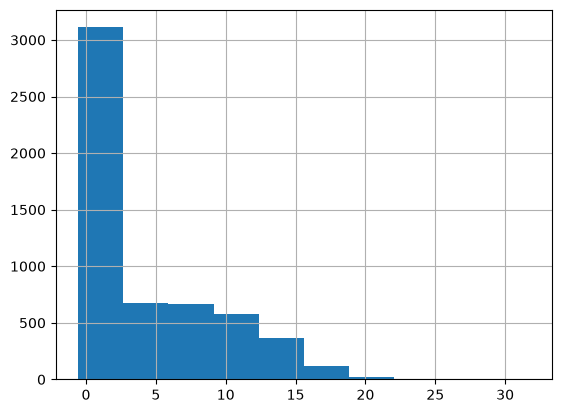

In [50]:
impuestos_df['OBS_VALUE'].hist()

Así, la base de datos que necesitamos construir es la siguiente:

In [51]:
impuestos_df = impuestos_df[['Reference area', 'TIME_PERIOD', 'Revenue category', 'OBS_VALUE']].rename(columns={'Reference area':'pais', 'TIME_PERIOD':'año', 'Revenue category':'tipo_impuesto', 'OBS_VALUE':'%gdp'})
impuestos_df

,pais,año,tipo_impuesto,%gdp
0,Philippines,2017,Taxes on payroll and workforce,0.000
1,Philippines,2016,Taxes on payroll and workforce,0.000
2,Philippines,2015,Taxes on payroll and workforce,0.000
3,Philippines,2014,Taxes on payroll and workforce,0.000
4,Philippines,2013,Taxes on payroll and workforce,0.000
...,...,...,...,...
5539,Antigua and Barbuda,2016,Social security contributions (SSC),3.059
5540,Honduras,2016,Social security contributions (SSC),3.136
5541,Italy,2016,Taxes on property,2.765
5542,Fiji,2010,Taxes on payroll and workforce,0.000


Sin embargo, como nuestro objetivo es estudiar cada impuesto por separado, con esta base de datos queremos hacer el proceso contrario a las anteriores. Queremos pasar a un formato ancho, en el que cada tipo de impuesto corresonda a una columna diferente. Esto es muy fácil de lograr usando la función `pivot` de pandas.

In [52]:
impuestos_df = impuestos_df.pivot(index = ['pais', 'año'], columns='tipo_impuesto', values='%gdp').reset_index()

In [53]:
impuestos_df

tipo_impuesto,pais,año,Other taxes,Social security contributions (SSC),Taxes on goods and services,"Taxes on income, profits and capital gains of individuals and corporations",Taxes on payroll and workforce,Taxes on property
0,Antigua and Barbuda,2009,0.0,2.369,13.298,2.946,0.0,1.347
1,Antigua and Barbuda,2010,0.0,2.681,14.027,2.972,0.0,1.590
2,Antigua and Barbuda,2011,0.0,2.632,14.273,2.237,0.0,1.475
3,Antigua and Barbuda,2012,0.0,2.552,14.435,2.386,0.0,1.828
4,Antigua and Barbuda,2013,0.0,3.527,13.331,2.649,0.0,1.426
...,...,...,...,...,...,...,...,...
932,Viet Nam,2014,0.0,4.005,8.515,5.178,0.0,0.031
933,Viet Nam,2015,0.0,4.195,8.999,4.946,0.0,0.030
934,Viet Nam,2016,0.0,4.546,9.268,4.520,0.0,0.026
935,Viet Nam,2017,0.0,4.621,9.063,4.703,0.0,0.027


Ahora cambiaremos los nombres, ya que están muy largos y difíciles de trabajar

In [54]:
cambios = {'Other taxes':'imp_otros', 
           'Social security contributions (SSC)': 'imp_ss', 
           'Taxes on goods and services': 'imp_bienes', 
           'Taxes on income, profits and capital gains of individuals and corporations':'imp_ingreso',
           'Taxes on payroll and workforce': 'imp_nomina',
           'Taxes on property': 'imp_propiedad'
           }

impuestos_df.rename(columns=cambios, inplace=True)

Veamos

In [55]:
impuestos_df

tipo_impuesto,pais,año,imp_otros,imp_ss,imp_bienes,imp_ingreso,imp_nomina,imp_propiedad
0,Antigua and Barbuda,2009,0.0,2.369,13.298,2.946,0.0,1.347
1,Antigua and Barbuda,2010,0.0,2.681,14.027,2.972,0.0,1.590
2,Antigua and Barbuda,2011,0.0,2.632,14.273,2.237,0.0,1.475
3,Antigua and Barbuda,2012,0.0,2.552,14.435,2.386,0.0,1.828
4,Antigua and Barbuda,2013,0.0,3.527,13.331,2.649,0.0,1.426
...,...,...,...,...,...,...,...,...
932,Viet Nam,2014,0.0,4.005,8.515,5.178,0.0,0.031
933,Viet Nam,2015,0.0,4.195,8.999,4.946,0.0,0.030
934,Viet Nam,2016,0.0,4.546,9.268,4.520,0.0,0.026
935,Viet Nam,2017,0.0,4.621,9.063,4.703,0.0,0.027


Ahora sí estamos listos para calcular los promedios usando nuestra función

In [56]:
impuestos_prom = calcular_promedios(impuestos_df, ['pais'], ['imp_otros', 'imp_ss', 'imp_bienes', 'imp_ingreso', 'imp_nomina', 'imp_propiedad'], [2015, 2018])
impuestos_prom

,index,imp_otros,imp_ss,imp_bienes,imp_ingreso,imp_nomina,imp_propiedad,año
0,Antigua and Barbuda,0.0000,2.8690,13.8574,2.4788,0.0000,1.5746,2015
1,Argentina,0.2934,6.6092,15.3120,5.3046,0.0000,2.7416,2015
2,Armenia,0.7814,1.9944,12.1012,6.1638,NaN,0.0000,2015
3,Asia and the Pacific,0.2170,1.4758,9.3000,6.8894,0.0896,0.6512,2015
4,Austria,0.2978,14.2072,11.8940,11.9776,2.8772,0.5814,2015
...,...,...,...,...,...,...,...,...
91,United Kingdom,0.0000,6.0220,10.8460,11.2548,0.0176,4.0148,2018
92,United States,0.0000,6.1580,4.3576,12.2692,0.0096,3.2298,2018
93,Uruguay,0.1442,6.8910,10.7740,5.6468,0.0000,2.0446,2018
94,Vanuatu,0.0000,0.0000,16.7500,0.0000,0.0000,0.5092,2018


Y finalmente agregamos esta información a la base de datos

In [57]:
pisa_df = pisa_df.merge(impuestos_prom, left_on=['pais','año'], right_on=['index', 'año'], how = 'left').drop(columns='index')
pisa_df

,pais,indicador,año,puntaje,poblacion,gdp_pc,ed_inv,imp_otros,imp_ss,imp_bienes,imp_ingreso,imp_nomina,imp_propiedad
0,Australia,lectura,2015,503.0,22.741811,45328.174485,3.407741,NaN,NaN,NaN,NaN,NaN,NaN
1,Austria,lectura,2015,485.0,8.439415,45942.192569,3.014982,0.2978,14.207200,11.8940,11.9776,2.8772,0.5814
2,Belgium,lectura,2015,499.0,11.052352,42333.382012,4.150655,0.0112,14.151000,11.1958,15.4208,0.0020,3.3198
3,Canada,lectura,2015,527.0,34.715766,42821.878643,3.351134,0.0364,4.655600,7.2780,14.7372,0.6506,3.7192
4,Chile,lectura,2015,459.0,17.432219,20936.429882,2.669501,0.0156,1.386400,10.5776,7.5538,0.0000,0.8444
...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,United Kingdom,ciencias,2018,505.0,65.100145,42773.919395,3.875473,0.0000,6.022000,10.8460,11.2548,0.0176,4.0148
242,United States,ciencias,2018,502.0,320.675831,56346.684972,3.207156,0.0000,6.158000,4.3576,12.2692,0.0096,3.2298
243,Brazil,ciencias,2018,404.0,203.431748,15040.744740,4.065232,0.0124,8.450000,14.2372,6.8502,0.6168,1.3558
244,Indonesia,ciencias,2018,396.0,256.474658,10527.761524,2.350309,1.2872,0.282667,5.2096,5.1656,0.0000,0.2458


Nuestra base de datos está completa, infortunamente podemos notar que hay algunos países que no tienen información de impuestos en su base de datos. Estos deberán ser removidos ya que no los podemos procesar.

In [58]:
pisa_df.describe()

,año,puntaje,poblacion,gdp_pc,ed_inv,imp_otros,imp_ss,imp_bienes,imp_ingreso,imp_nomina,imp_propiedad
count,246.000000,238.000000,246.000000,246.000000,243.000000,234.000000,231.000000,234.000000,234.000000,234.000000,234.000000
mean,2016.500000,483.197479,46.741110,36988.595491,3.217286,0.207918,8.875913,10.784462,10.369197,0.389015,1.742172
std,1.503058,35.459118,70.471057,16817.691704,0.659927,0.388725,4.605938,2.917574,4.802361,0.861933,1.155828
min,2015.000000,371.000000,0.321784,9651.823498,2.003602,-0.163000,0.000000,4.337000,3.849200,0.000000,0.245800
25%,2015.000000,474.250000,5.413212,25444.600916,2.669501,0.000000,5.805800,9.143200,6.786800,0.000000,0.892000
50%,2016.500000,493.000000,10.933803,35777.462101,3.159353,0.035800,9.722400,11.366600,9.426400,0.002000,1.374700
75%,2018.000000,505.750000,60.195879,45902.382341,3.652897,0.224800,12.538400,12.273400,12.761400,0.312400,2.556600
max,2018.000000,538.000000,320.675831,108239.123049,4.704337,1.974800,16.755400,16.690200,29.442600,4.630600,4.992000


Este análisis nos permite ver si hay alguna columna que tiene muchos menos datos que las demás. Los impuestos, en general, tienen información faltante, pero no es una pérdida demasiado grande. Procedamos a eliminar las filas con valores faltantes.

In [59]:
pisa_df.dropna(axis ='index', inplace=True)
pisa_df

,pais,indicador,año,puntaje,poblacion,gdp_pc,ed_inv,imp_otros,imp_ss,imp_bienes,imp_ingreso,imp_nomina,imp_propiedad
1,Austria,lectura,2015,485.0,8.439415,45942.192569,3.014982,0.2978,14.207200,11.8940,11.9776,2.8772,0.5814
2,Belgium,lectura,2015,499.0,11.052352,42333.382012,4.150655,0.0112,14.151000,11.1958,15.4208,0.0020,3.3198
3,Canada,lectura,2015,527.0,34.715766,42821.878643,3.351134,0.0364,4.655600,7.2780,14.7372,0.6506,3.7192
4,Chile,lectura,2015,459.0,17.432219,20936.429882,2.669501,0.0156,1.386400,10.5776,7.5538,0.0000,0.8444
5,Colombia,lectura,2015,425.0,44.988446,12577.701689,3.159353,0.6970,1.935400,8.0452,6.0052,0.6034,1.9780
...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,Türkiye,ciencias,2018,468.0,78.227739,25444.600916,2.520684,0.3684,7.120400,11.0246,5.1822,0.0000,1.1798
241,United Kingdom,ciencias,2018,505.0,65.100145,42773.919395,3.875473,0.0000,6.022000,10.8460,11.2548,0.0176,4.0148
242,United States,ciencias,2018,502.0,320.675831,56346.684972,3.207156,0.0000,6.158000,4.3576,12.2692,0.0096,3.2298
243,Brazil,ciencias,2018,404.0,203.431748,15040.744740,4.065232,0.0124,8.450000,14.2372,6.8502,0.6168,1.3558


Ahora sí, nos quedamos sólo con datos completos para los países

# Regresión Lineal para establecer qué favorece los buenos resultados
Ahora vamos a implementar un modelo de regresión lineal con el que podamos analizar cuáles son las características económicas del país que favorecen los buenos resultados en las pruebas. Sin embargo, antes de construir el modelo, creemos algunas variables adicionales 

### El GDP total
Este se calcula como el GDP per capita (`gdp_pc`) multiplicado por la población total (`poblacion`), como estamos trabajando sobre promedios, el resultado es solo una aproximación.

In [60]:
pisa_df['gdp_total'] = pisa_df['gdp_pc']*pisa_df['poblacion']

### La inversión en educación per capita
Idealmente se debería hacer este cálculo con la población estudiantil, pero usemos la población total como referencia. El cálculo es entonces<br>

(inversión en educacion)(gdp total)/(poblacion)

In [61]:
pisa_df['inv_ed_pc'] = pisa_df['ed_inv']*pisa_df['gdp_total']/pisa_df['poblacion']

### Los impuestos totales recaudados
El impuesto total recaudado es la suma de todos los impuestos en la base de datos

In [62]:
pisa_df['imp_total'] = pisa_df['imp_bienes']+pisa_df['imp_ss']+pisa_df['imp_ingreso']+pisa_df['imp_nomina']+pisa_df['imp_otros']+pisa_df['imp_propiedad']

Veamos como queda finalmente nuestra base de datos

In [63]:
pisa_df

,pais,indicador,año,puntaje,poblacion,gdp_pc,ed_inv,imp_otros,imp_ss,imp_bienes,imp_ingreso,imp_nomina,imp_propiedad,gdp_total,inv_ed_pc,imp_total
1,Austria,lectura,2015,485.0,8.439415,45942.192569,3.014982,0.2978,14.207200,11.8940,11.9776,2.8772,0.5814,3.877252e+05,138514.898949,41.835200
2,Belgium,lectura,2015,499.0,11.052352,42333.382012,4.150655,0.0112,14.151000,11.1958,15.4208,0.0020,3.3198,4.678834e+05,175711.272180,44.100600
3,Canada,lectura,2015,527.0,34.715766,42821.878643,3.351134,0.0364,4.655600,7.2780,14.7372,0.6506,3.7192,1.486594e+06,143501.870595,31.077000
4,Chile,lectura,2015,459.0,17.432219,20936.429882,2.669501,0.0156,1.386400,10.5776,7.5538,0.0000,0.8444,3.649684e+05,55889.824694,20.377800
5,Colombia,lectura,2015,425.0,44.988446,12577.701689,3.159353,0.6970,1.935400,8.0452,6.0052,0.6034,1.9780,5.658513e+05,39737.394534,19.264200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,Türkiye,ciencias,2018,468.0,78.227739,25444.600916,2.520684,0.3684,7.120400,11.0246,5.1822,0.0000,1.1798,1.990474e+06,64137.798414,24.875400
241,United Kingdom,ciencias,2018,505.0,65.100145,42773.919395,3.875473,0.0000,6.022000,10.8460,11.2548,0.0176,4.0148,2.784588e+06,165769.169721,32.155200
242,United States,ciencias,2018,502.0,320.675831,56346.684972,3.207156,0.0000,6.158000,4.3576,12.2692,0.0096,3.2298,1.806902e+07,180712.620059,26.024200
243,Brazil,ciencias,2018,404.0,203.431748,15040.744740,4.065232,0.0124,8.450000,14.2372,6.8502,0.6168,1.3558,3.059765e+06,61144.110805,31.522400


Estamos listos para construir nuestro modelo. Lo primero que haremos será enfocarnos en algún indicador. Empecemos, por ejemplo, por lectura:

In [64]:
lectura_df = pisa_df[pisa_df['indicador']=='lectura']

Ahora, guardaremos en un DataFrame `y` los valores promedio de la prueba para el país

In [65]:
y = lectura_df['puntaje']

In [66]:
y

1      485.0
2      499.0
3      527.0
4      459.0
5      425.0
       ...  
158    466.0
159    504.0
160    505.0
161    413.0
162    371.0
Name: puntaje, Length: 73, dtype: float64

Ahora guardaremos en un nuevo DataFrame X la información de todas las variables que queremos estudiar como posibles desencadenadores de los resultados de la prueba:

In [67]:
X = lectura_df.drop(columns=['pais', 'año', 'puntaje', 'indicador'])
X

,poblacion,gdp_pc,ed_inv,imp_otros,imp_ss,imp_bienes,imp_ingreso,imp_nomina,imp_propiedad,gdp_total,inv_ed_pc,imp_total
1,8.439415,45942.192569,3.014982,0.2978,14.207200,11.8940,11.9776,2.8772,0.5814,3.877252e+05,138514.898949,41.835200
2,11.052352,42333.382012,4.150655,0.0112,14.151000,11.1958,15.4208,0.0020,3.3198,4.678834e+05,175711.272180,44.100600
3,34.715766,42821.878643,3.351134,0.0364,4.655600,7.2780,14.7372,0.6506,3.7192,1.486594e+06,143501.870595,31.077000
4,17.432219,20936.429882,2.669501,0.0156,1.386400,10.5776,7.5538,0.0000,0.8444,3.649684e+05,55889.824694,20.377800
5,44.988446,12577.701689,3.159353,0.6970,1.935400,8.0452,6.0052,0.6034,1.9780,5.658513e+05,39737.394534,19.264200
...,...,...,...,...,...,...,...,...,...,...,...,...
158,78.227739,25444.600916,2.520684,0.3684,7.120400,11.0246,5.1822,0.0000,1.1798,1.990474e+06,64137.798414,24.875400
159,65.100145,42773.919395,3.875473,0.0000,6.022000,10.8460,11.2548,0.0176,4.0148,2.784588e+06,165769.169721,32.155200
160,320.675831,56346.684972,3.207156,0.0000,6.158000,4.3576,12.2692,0.0096,3.2298,1.806902e+07,180712.620059,26.024200
161,203.431748,15040.744740,4.065232,0.0124,8.450000,14.2372,6.8502,0.6168,1.3558,3.059765e+06,61144.110805,31.522400


Note como en `X` no aparecen variables relacionadas con el nombre del país, o el año. Estas no serán tenidos en cuenta dentro del modelo.

<Axes: >

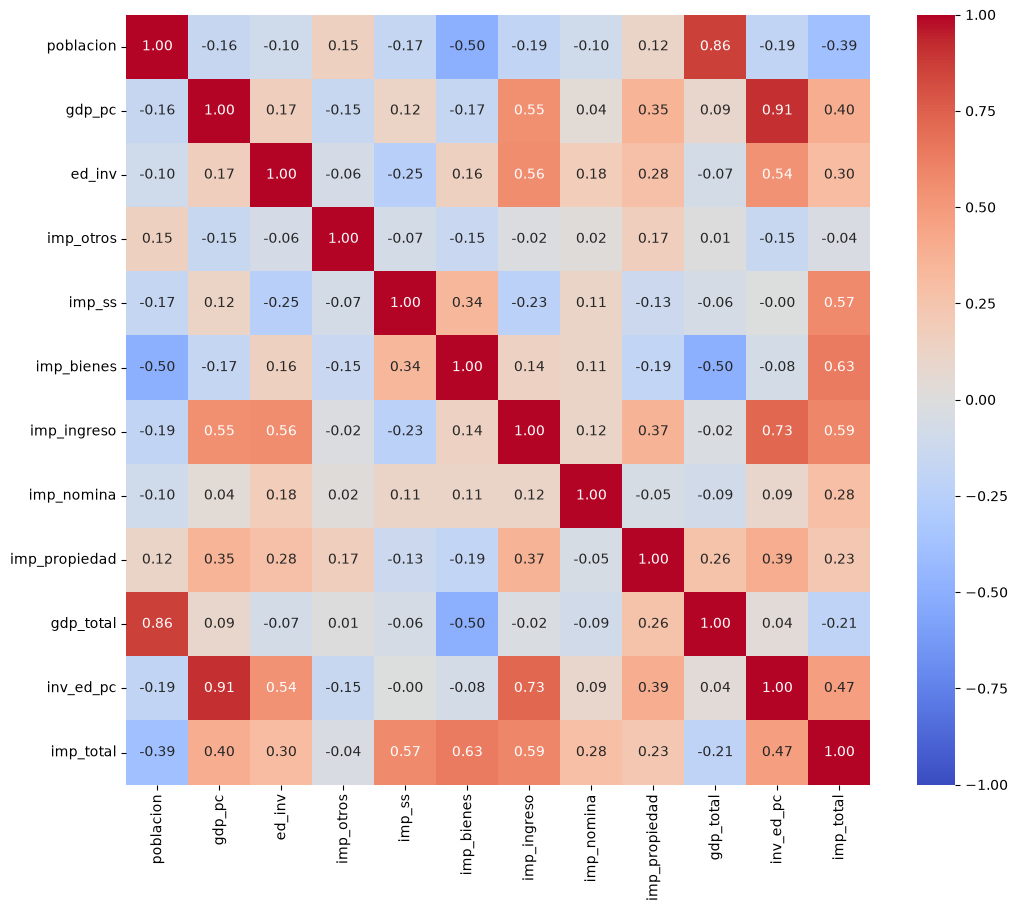

In [68]:
plt.figure(figsize=(12, 10))  # Adjust figure size as needed
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin= -1, vmax = 1)

## Regresión Lineal
Ahora implementemos una regresión lineal simple usando la librería `statsmodels` y la funcion OLS.

In [69]:
# definimos el modelo
model = sm.OLS(y, sm.add_constant(X))

# ajustamos el modelo
results = model.fit()

Ahora podemos proceder a ver el resultado del ajuste

In [70]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                puntaje   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     10.88
Date:              vie., 31 jul. 2026   Prob (F-statistic):           9.39e-11
Time:                        18:25:06   Log-Likelihood:                -317.02
No. Observations:                  73   AIC:                             658.0
Df Residuals:                      61   BIC:                             685.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           479.5227     33.541     14.297

El modelo no es perfecto, pero logra captar mucha de la variación en los resultados. Sin embargo, su interpretación es difícil debido a que las variables tienen unidades muy diferentes. Una buena práctica es escalar las variables para poder interpretar los coeficientes de forma directa:

In [71]:
# Haciendo un escalamiento estandar de las variables
X_scaled = (X-X.mean(axis = 0))/X.std(axis = 0)

In [72]:
# definimos el modelo
model = sm.OLS(y, sm.add_constant(X_scaled))

# ajustamos el modelo
results = model.fit()

Veamos los nuevos resultados

In [73]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                puntaje   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     10.88
Date:              vie., 31 jul. 2026   Prob (F-statistic):           9.39e-11
Time:                        18:29:48   Log-Likelihood:                -317.02
No. Observations:                  73   AIC:                             658.0
Df Residuals:                      61   BIC:                             685.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           483.4795      2.383    202.887

## Evaluando los resultados de la Regresión


### Normalidad de los residuos
Una vez tenemos el resultado de la regresión debemos evaluar su integridad para garantizar la confiabilidad de los resultados. La primera verificación que debemos hacer es la de la normalidad de los residuales. Los residuales son las diferencias entre los resultados predichos por el modelo lineal y los resultados reales. La teoría detrás de la regresión lineal, el cálculo de los coeficientes y sus variaciones, asume que los residuos deben estar normalmente distribuidos.

Veamos los residuos gráficamente

<Axes: >

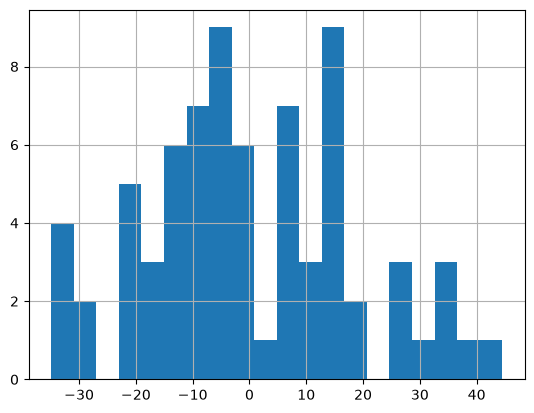

In [74]:
# Calculamos los residuos
residuos = results.resid

# Graficamos la distribución
residuos.hist(bins = 20)

Aunque la distribución es relativamente simétrica alrededor de 0, es difícil determinar si tenemos una distribución normal o no. Para hacer esto, podemos apoyarnos de técnicas estadísticas como la prueba de Jarque-Bera. Veamos

In [75]:
from statsmodels.compat import lzip
# Importamos la utilidad para realizar el contraste
from statsmodels.stats.stattools import jarque_bera

# Realizamos el contraste 
test=jarque_bera(residuos)


# Imprimimos los resultados
print('Estadístico: ', test[0])
print('p_valor: ', test[1])
print('Asimetría:', test[2])
print('Curtosis: ', test[3])

Estadístico:  1.2053348836961921
p_valor:  0.5473496636992181
Asimetría: 0.23723428510489547
Curtosis:  2.586292303438583


Interpretación de los diferentes resultados del test:

- Estadístico: el estadístico en la prueba de Jarque-Bera mide qué tanto la distribución difiere de la distribución normal. Entre más grande el valor, más disímil es la distribución de la distrbución normal.
- p-valor: la prueba de Jarque-Bera es una prueba de hipótesis en la que la hipótesis nula es que los residuos siguen una distribución normal. Entonces el p-valor debe ser interpretado de la manera siguiente: *la probabilidad de observar la distribución de residuos evaluada asumiendo que la distribución de residuos es normal*. Así, si el p-valor es muy pequeño (p_valor < 0.05) se puede rechazar la hipótesis nula y concluir que la distribución no es normal. En este caso, el p-valor es 0.54, lo que sugiere que hay una alta probabilidad de observar la distribución de residuos que obtuvimos asumiendo una distribución normal.
- Asimetría (Skewness): este valor también es reportado en la salida de statsmodels, y corresponde a la asimetría de la distribución. Entre más pequeño este valor, más simétrica es la distribución.
- Curtosis (kurtosis): también reportado en statsmodels, es una medida de la longitud de las colas de la distribución con respecto al ancho de la distribución. Para una distribución normal, este valor debe estar cercano al 3.


En conclusión, el análisis de Jarque-Bera sugiere que los residuos siguen adecuadamente una distribución normal, no hay evidencia estadística para concluir lo contrario.

## Homocedasticidad de los residuos

Otra suposición de la regresión lineal es la independencia de la varianza de los residuos con la variable dependiente. Esto se puede verificar de forma gráfica o también con pruebas estadísticas, veamos:

<Axes: xlabel='puntaje', ylabel='None'>

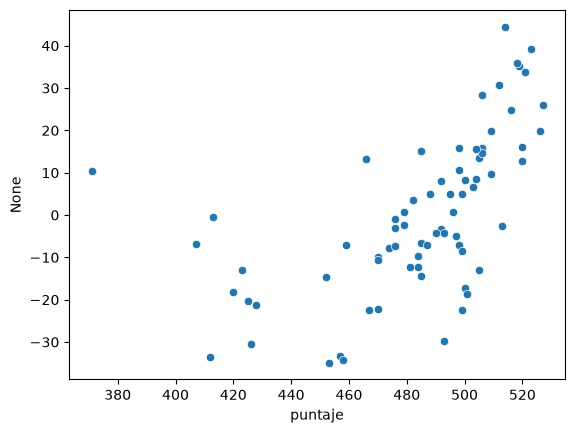

In [76]:
# Evaluación gráfica de los residuos

sns.scatterplot(x= y, y=residuos)

Como vemos, los residuos no se encuentran distribuidos alrededor de 0, son negativos para puntajes bajos, y son positivos para puntajes altos. Lo que evidencia las limitaciones de nuestro modelo para capturar completamente el comportamiento de los resultados de las pruebas. Sin embargo, la dispersión de los residuos no parece mostrar variaciones significativas a lo largo de la gráfica.  

Esto lo podemos confirmar con la prueba estadística de Breusch-Pagan

In [77]:
import statsmodels.stats.api as sms

# aplicando el test Breusch-Pagan
bptest=sms.het_breuschpagan(residuos,sm.add_constant(X_scaled))

# Imprimiendo los resultados
print('Lagrange multiplier statistic: ', bptest[0])
print('p-valor: ', bptest[1])

Lagrange multiplier statistic:  11.304289400233628
p-valor:  0.5030367219217047


Interpretación de los resultados:

El test Breush-Pagan arroja una serie de valores, pero nos interesan principalmente los primeros dos:
- Lagrange multiplier statistic: es un parámetro que mide la heterocedasticidad, entre más grande sea, mayor evidencia de heterocedasticidad (varianza variable).
- p-valor: en la prueba de Breusch-Pagan, la hipótesis nula es que la varianza es constante, es decir, que los residuos son homocedasticos. El p-valor se debe interpretar entonces como: *la probabilidad de encontrar una distribución de los residuos como la observada asumiendo que la varianza de los residuos es constante*. Si el p-valor es muy pequeño (p_valor<0.05) se puede rechazar la hipótesis nula y concluir que no hay homocedasticidad (hay heterocedasticidad).

Conclusión:

Un p-valor de 0.503 no es lo suficientemente pequeño como para rechazar la hipótesis nula, de manera que no tenemos la suficiente evidencia estadística como para sugerir que los residuos no son homocedásticos.

## Multicolinearidad

Un problema para los modelos de regresión, y para cualquier modelo de Machine Learning, es la multicolinearidad, es decir, la correlación significativa entre las variables de entrada. Numéricamente, la salida de stats-models con la variable `Cond. No.` nos sugiere que hay una multicolinearidad significativa en el modelo que se entregó. Este valor debe ser lo más pequeño posible (<30) para asegurar que no hay problemas de multicolinearidad.

Para evaluar la correlación entre variables se pueden hacer pruebas de correlación entre las variables de entrada y crear la llamada matriz de correlación:

Text(0.5, 1.0, 'Correlation Matrix of Input Variables')

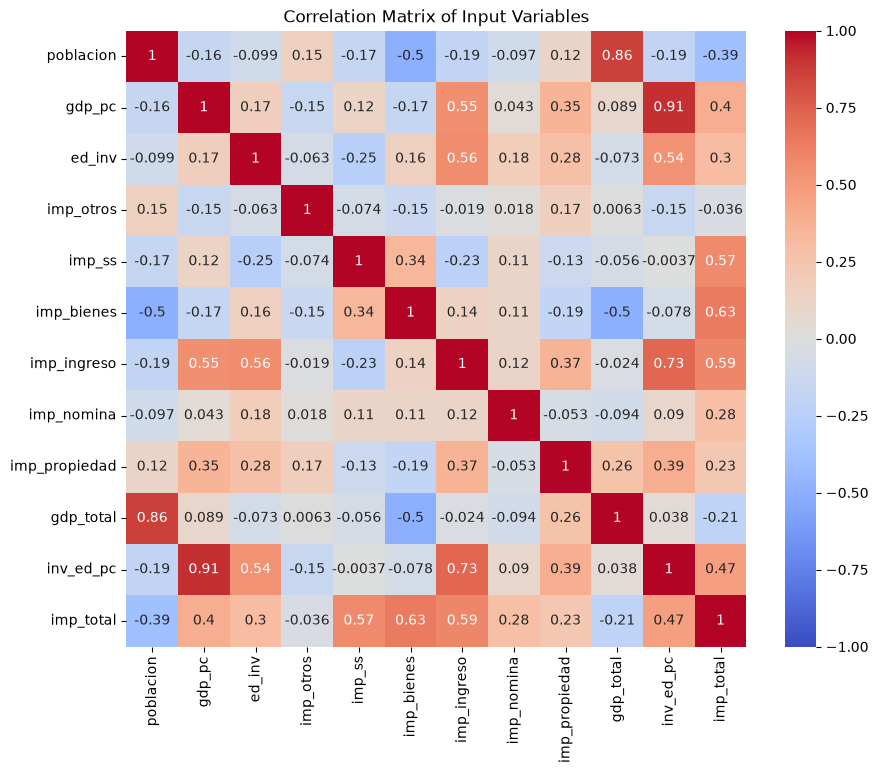

In [78]:
# calculando la correlación entre las variables de entrada
correlation_matrix = X_scaled.corr()

# Graficando la correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Input Variables')


Encontramos una alta correlación entre varias variables, por ejemplo el gdp_total está fuertemente correlacionado con la población, o el gdp per capita está altamente correlacionado con la inversión en educación per capita.

# Estrategias para reducir la multicolinearidad

## Regularización:
La regularización es un método que se aplica cuando se tienen demasiadas variables en un modelo y se quiere escoger cuáles son las más importantes sin llegar a comprometer significativamente la calidad del ajuste. Para lograr esto, a la función de minimización se le agregará un término adicional que es proporcional al tamaño de los coeficientes obtenidos (por eso es importante que la escala de los coeficientes sea la misma). Existen dos tipos principales de regularización que tienen dos aplicaciones diferentes:

##### Regularización tipo Lasso - L1:

En la regularización tipo Lasso, la función a minimizar tiene la forma: <br>
$\displaystyle L_1 = \text{0.5}\text{MSE}+\alpha \sum_{j=1}^M |C_m|$ <br>
en donde MSE es el usual error cuadrático medio, $C_m$ es el coeficiente obtenido para el parámetro $m$, $M$ es el número total de parámetros, y $\alpha$ es un parámetro que determina qué tan fuerte es la regularización. La regularización L1 es la más comunmente utilizada para seleccionar las variables principales en un modelo de regresión.

##### Regularización tipo Ridge - L2:

En este tipo de regularización, la función a minimizar tiene la forma: <br>
$\displaystyle L_2 = \text{0.5}\text{MSE}+\alpha \sum_{j=1}^M C_m^2$ <br>
Es decir, en este caso no se usa el valor absoluto sino el cuadrado de los coeficientes. Este tipo de regularización se utiliza más comunmente para reducir efectos de *overfitting*. El *overfitting* es un efecto que ocurre cuando se usan demasiadas variables y consiste en que el modelo ajustado reproduce muy bien los datos que se usaron para ajustar, pero es muy malo para reproducir datos no utilizados durante el ajuste. Cuando hay *overfitting* el modelo no funciona bien para hacer predicciones.

## Implementando una Regularización tipo L1

El siguiente es el código para implementar regularización en statsmodels, el parámetro `L1_wt=1` fija la regularización al tipo L1, el parámetro `alpha=0.02` fija la fuerza de la regularización, entre más grande más fuerte será la regularización.  

In [79]:
modelo=sm.OLS(y,sm.add_constant(X_scaled)).fit_regularized(L1_wt=1, alpha = 0.02)

Infortunadamente, en este caso la función `summary` no está bien implementada y debemos calcular el R-squared nosotros mismos usando la definición:

$\displaystyle R^2 = 1 - \frac{\sum (y_i-\hat{y}_i)^2}{\sum (y_i-\bar{y})^2}$ 

En donde $y_i$ son los valores observados, $\hat{y}_i$ son los valores predichos por le modelo, y $\bar{y}$ es el valor promedio de los valores observados.

In [80]:
R = 1 - ((y - modelo.fittedvalues)**2).sum()/((y-y.mean())**2).sum()
print('R-squared: ',R)

R-squared:  0.6615050550438123


Como vemos, en este caso, el $R^2$ es similar al obtenido anteriormente. También podemos calcular el `Cond. No` para evaluar multicolinearidad. Para hacerlo primero debemos encontrar cuáles parámetros tienen coeficientes diferentes de 0, y calcular el Condition Number sólo con esos parámetros

In [81]:
# Sacamos los coeficientes
coefficients = modelo.params

# Encontramos los coeficientes diferentes de 0, hay que quitar la constante, ya que no está en la base original
non_zero_indices = np.where(np.abs(coefficients.drop('const')) > 1e-6)[0]  # Se deja un pequeño rango de tolerancia

# calculamos el Condition Number
X_reduced = X_scaled.iloc[:, non_zero_indices]
cond_no = np.linalg.cond(X_reduced)

# Imprimimos
print("Condition Number (Cond. No.):", cond_no)

Condition Number (Cond. No.): 5241288411767050.0


El `Cond. No` es aún muy grande, lo que sugiere que podemos mejorar. A continuación lo que haremos será escanear el valor del parámetro `alpha` y estudiar sus efectos sobre $R^2$ (calidad del ajuste) y Cond. No (multicollinariedad)

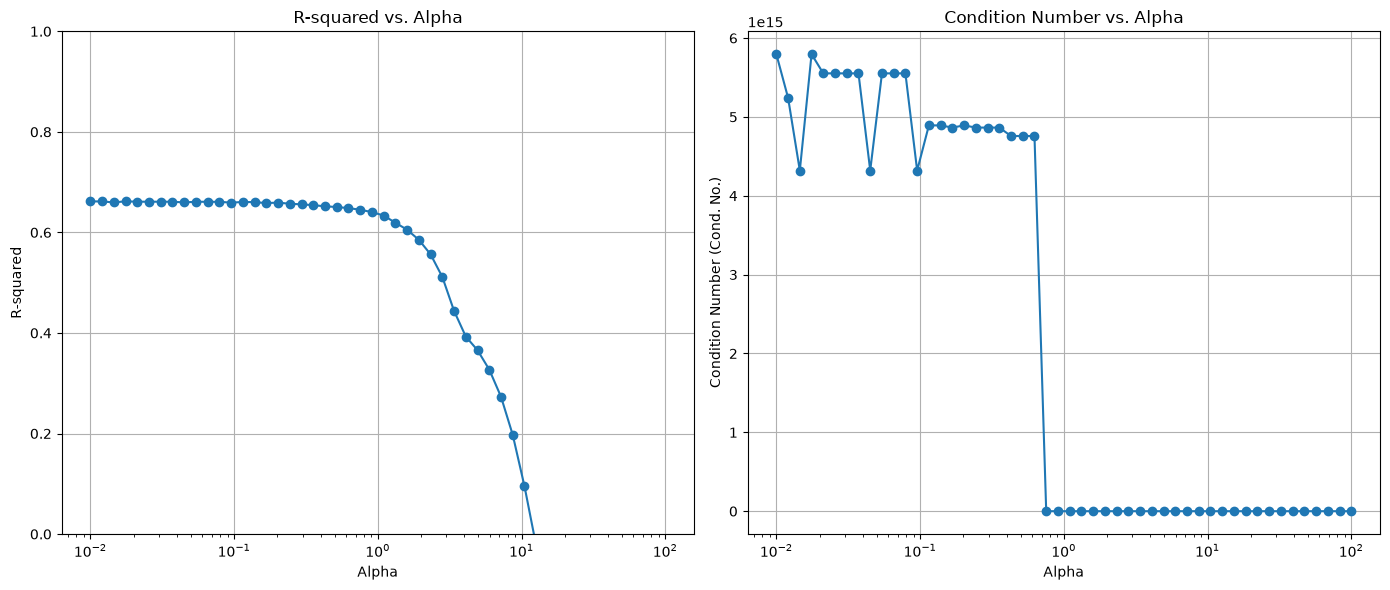

In [82]:
r2_scores = [] # valores de r2
cond_numbers = [] # valores de cond_no

# generamos un rango de valores de alpha
alpha_values = np.logspace(-2, 2, 50)  # Escala logarítmica de 0.01 a 100

for alpha in alpha_values:
    # Ajustamos el modelo
    modelo = sm.OLS(y, sm.add_constant(X_scaled)).fit_regularized(L1_wt=1, alpha=alpha)

    # Calculamos R2
    R2 = 1 - ((y - modelo.fittedvalues)**2).sum()/((y-y.mean())**2).sum()
    # Sacamos los coeficientes
    coefficients = modelo.params
    # Encontramos los coeficientes diferentes de 0
    non_zero_indices = np.where(np.abs(coefficients.drop('const')) > 1e-6)[0]  # Se deja un pequeño rango de tolerancia
    # calculamos el Condition Number pero solo si hay coeficientes
    if len(non_zero_indices)>0:
        X_reduced = X_scaled.iloc[:, non_zero_indices]
        cond_no = np.linalg.cond(X_reduced)
    else: # si no, hacemos cond_no = 0
        cond_no = 0

    # Agregamos los resultados
    r2_scores.append(R2)
    cond_numbers.append(cond_no)

# Graficamos los resultados
plt.figure(figsize=(14, 6))

# R-squared
plt.subplot(1, 2, 1)
plt.plot(alpha_values, r2_scores, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R-squared')
plt.title('R-squared vs. Alpha')
plt.ylim(0,1)
plt.grid(True)

# Condition Number
plt.subplot(1, 2, 2)
plt.plot(alpha_values, cond_numbers, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Condition Number (Cond. No.)')
plt.title('Condition Number vs. Alpha')
plt.grid(True)

plt.tight_layout()
plt.show()

En efecto, a medida que `alpha` aumenta, el valor de R2 disminuye, ya que estamos quitándole información al modelo. Sin embargo, los principales efectos sobre R2 se ven para valores de `alpha` mayores a 2, para los que R2 cae por debajo de 0.6. Por el lado de Condition Number, notamos que para valores de `alpha` mayores de 0.7 aproximadamente hay una caida significativa, sugiriendo que el modelo elimina significativamente la multicolinearidad.

Repitamos el modelo para `alpha = 0.7`

In [83]:
# Ajustamos el modelo con alpha = 0.7
modelo=sm.OLS(y,sm.add_constant(X_scaled)).fit_regularized(L1_wt=1, alpha = 0.7)

# cálculo de R2
R = 1 - ((y - modelo.fittedvalues)**2).sum()/((y-y.mean())**2).sum()
print('R-squared: ',R)

# Sacamos los coeficientes
coefficients = modelo.params

# Encontramos los coeficientes diferentes de 0
non_zero_indices = np.where(np.abs(coefficients.drop('const')) > 1e-6)[0]  # Se deja un pequeño rango de tolerancia
# calculamos el Condition Number
X_reduced = X_scaled.iloc[:, non_zero_indices]
cond_no = np.linalg.cond(X_reduced)

# Imprimimos
print("Condition Number (Cond. No.):", cond_no)

R-squared:  0.6466148462391357
Condition Number (Cond. No.): 5.294144769437159


Como vemos, con `alpha=0.7` el modelo todavía tiene un muy buen R2 de 0.6466 (64% de variaciones de los resultados se explican con las variables de entrada) y tenemos un valor muy bajo del Condition Number de 5.29. Lo que sugiere que el modelo ya no tiene problemas significativos de multicolinearidad.

Revisemos entonces con qué variables nos quedamos

In [84]:
X_scaled.iloc[:, non_zero_indices].columns

Index(['poblacion', 'imp_otros', 'imp_ss', 'imp_bienes', 'imp_ingreso',
       'imp_nomina', 'imp_propiedad', 'gdp_total'],
      dtype='str')

El proceso de regularización nos sugiere que las variables que necesitamos para explicar el modelo son:
- Población total
- Otros impuestos
- Impuestos seguridad social
- Impuestos bienes
- Impuesto ingreso
- Impuesto nomina
- Impuesto propiedad
- gdp_total

Corramos el modelo usando sólo estas variables

In [85]:
# definimos el modelo
model = sm.OLS(y, sm.add_constant(X_scaled.iloc[:, non_zero_indices]))

# ajustamos el modelo
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                puntaje   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     15.20
Date:              vie., 31 jul. 2026   Prob (F-statistic):           3.09e-12
Time:                        18:40:22   Log-Likelihood:                -317.79
No. Observations:                  73   AIC:                             653.6
Df Residuals:                      64   BIC:                             674.2
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           483.4795      2.351    205.632

Como se observa, ya no tenemos alarmas de multicolinearidad y el valor de `Cond. No. = 5.29` está dentro de los niveles aceptados. Veamos ahora qué ocurre cuando graficamos la matriz de correlación:

Text(0.5, 1.0, 'Correlation Matrix of Input Variables')

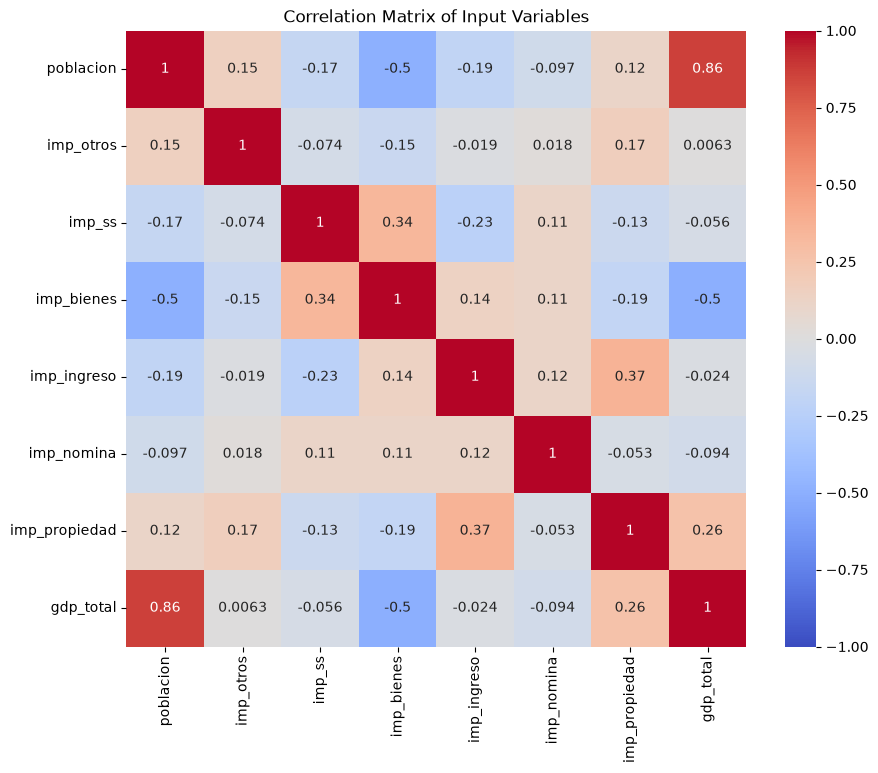

In [86]:
# calculando la correlación entre las variables de entrada
correlation_matrix = X_scaled.iloc[:, non_zero_indices].corr()

# Graficando la correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Input Variables')

Las correlaciones fuertes han sido, en su mayoría retiradas. Existen todavía variables con alta correlación como la población y el gdp, sin embargo, el modelo es capaz de detectar que tienen tendencias opuestas: la población desfavorece los resultados, el gdp favorece los buenos resultados.

### Eliminando variables no importantes para el modelo

En general, la interpretabilidad de un modelo de regresión se puede ver afectada por las variables no significativas del modelo, y en este punto aún tenemos varias variables con p-valores mayores a 0.05, es decir, no estadísticamente significativas.

Para escoger las variables más relevantes del modelo podemos introducir un algoritmo de selección de variables denominado StepWise Regression, el algoritmo se puede entender de la siguiente manera:

- Arrancamos sin `caracteristicas_iniciales`, todas las variables son `caracteristicas_por_evaluar`
- Tomamos todas las variables una por una y creamos un modelo con esa única variable, miramos cuál entrega el menor valor del p-valor. Esta variable entra a `caracteristicas_iniciales` y se saca de `caracteristicas_por evaluar`.
- Tomamos todas las variables restantes en `características_por_evaluar` y las agregamos una por una al modelo junto con las variables en `caracteristicas_iniciales`, seleccionamos la de menor p-valor siempre que sea significativ. Esta variable se agrega a `caracteristicas_iniciales` y se remueve de `caracteristicas por evaluar`.
- Seguimos hasta que al evaluar todas las `caracteristicas_por_evaluar` no encontremos ninguna estadísticamente significativa.


In [87]:
def seleccion_por_pasos(datos, objetivo, nivel_significancia=0.05):
    # Lista para guardar las características inicialmente seleccionadas
    caracteristicas_iniciales = []
    
    # Lista de características que quedan por evaluar
    caracteristicas_restantes = list(datos.columns)
    
    # Lista de las mejores características seleccionadas
    mejores_caracteristicas = []
    
    while caracteristicas_restantes:
        mejor_p_valor = float('inf')
        mejor_caracteristica = None
        
        # Probar cada característica restante agregándola al modelo
        for caracteristica in caracteristicas_restantes:
            # Construir el modelo con las características actuales más la candidata
            caracteristicas = caracteristicas_iniciales + [caracteristica]
            X = sm.add_constant(datos[caracteristicas])
            modelo = sm.OLS(objetivo, X).fit()
            
            # Verificar el p-valor de la característica candidata
            p_valor = modelo.pvalues[caracteristica]
            
            # Verificar si el p-valor es el mejor hasta ahora y está por debajo del nivel de significancia
            if p_valor < mejor_p_valor and p_valor < nivel_significancia:
                mejor_p_valor = p_valor
                mejor_caracteristica = caracteristica
        
        # Si se encontró una nueva característica que mejora el modelo, agregarla a las características seleccionadas
        if mejor_caracteristica:
            caracteristicas_iniciales.append(mejor_caracteristica)
            caracteristicas_restantes.remove(mejor_caracteristica)
            mejores_caracteristicas.append(mejor_caracteristica)
            print(f"Se agregó la característica '{mejor_caracteristica}' con p-valor {mejor_p_valor:.4f}")
        else:
            # Si no se encuentra ninguna característica nueva significativa, detener el proceso
            break

    return mejores_caracteristicas

# Ejemplo de uso
# Suponiendo que `X` es tu DataFrame de características y `y` es tu variable objetivo
caracteristicas_seleccionadas = seleccion_por_pasos(X_scaled, y)

print("Características seleccionadas:", caracteristicas_seleccionadas)

# Ajustar el modelo final con las características seleccionadas
X_final = sm.add_constant(X_scaled[caracteristicas_seleccionadas])
modelo_final = sm.OLS(y, X_final).fit()
print(modelo_final.summary())

Se agregó la característica 'imp_total' con p-valor 0.0000
Se agregó la característica 'imp_otros' con p-valor 0.0012
Se agregó la característica 'imp_bienes' con p-valor 0.0004
Se agregó la característica 'poblacion' con p-valor 0.0140
Se agregó la característica 'gdp_total' con p-valor 0.0000
Características seleccionadas: ['imp_total', 'imp_otros', 'imp_bienes', 'poblacion', 'gdp_total']
                            OLS Regression Results                            
Dep. Variable:                puntaje   R-squared:                       0.636
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     23.44
Date:              vie., 31 jul. 2026   Prob (F-statistic):           1.55e-13
Time:                        18:41:35   Log-Likelihood:                -319.74
No. Observations:                  73   AIC:                             651.5
Df Residuals:                      67   BIC:         

Como vemos, este algoritmo nos permite identificar filtrar aún más el resultado anterior y reducir nuestras variables a solamente 5, todas estadísticamente significativas:

- imp_total: 16.09 influye positivamente en las pruebas
- imp_otros: -7.3482 influye negativamente en las pruebas
- imp_bienes: -9.2082 influye negativamente en las pruebas
- población: -29.9351 influye negativamente en las pruebas
- gdp_total: 25.69 influye positivamente en las pruebas

Con estas 5 variables se pueden explicar el 63.6% de las variaciones en los resultados de las pruebas entre países.

# Conclusión

Hemos logrado construir una base de datos con información económica y demográfica de los paises, con la que hemos logrado explicar un 63.6% de las variaciones en los resultados de las pruebas PISA, en el área de lectura. Un análisis de la regresión lineal permite encontrar cuáles son los factores más importantes a la hora de determinar los resultados en las pruebas. Países pequeños y con GDP altos, son los que tienden a tener los mejores resultados.